# scCS Tutorial — Multi-Condition Analysis with `MultiScorer`

This tutorial demonstrates `MultiScorer` — the scCS class for analyses with **3 or more conditions** — on a real-data illustrative example: the **scVelo pancreatic endocrinogenesis** dataset stratified by per-cell RNA-velocity magnitude into **three tertiles** (`low_velocity`, `med_velocity`, `high_velocity`).

> The velocity-tertile split is an **illustrative stratification**, not a biological perturbation. In a real experiment, `condition_obs_key` would point to actual experimental conditions (e.g., `drug`, `genotype`, `timepoint`). The downstream patterns shown here — per-condition driver discovery, pathway enrichment, expression trends — work identically on real biological condition labels.

### What's covered
1. Loading pancreas data and creating the 3-way velocity-tertile split
2. Initializing `MultiScorer` and fitting the shared embedding
3. **Tier 1** — Score all conditions on the shared embedding
4. **Tier 2** — Omnibus tests (Kruskal-Wallis / ANOVA) + post-hoc pairwise comparisons
5. **Tier 3** — Mixed-effects models with reference contrasts
6. Standard multi-condition visualizations
7. **Driver genes per condition** (velocity + DEG)
8. **Pathway enrichment per condition**
9. **Expression trends along fate arms per condition**
10. **Transfer per-cell labels back to the full AnnData**

For 2-condition comparisons use `PairScorer` (see `scCS_tutorial_pairwise.ipynb`).


In [1]:
%matplotlib inline
import warnings, numpy as np, pandas as pd
import anndata as ad
import scanpy as sc, scvelo as scv
import matplotlib.pyplot as plt
import scCS

from scCS.drivers import (
    get_velocity_drivers,
    get_deg_drivers,
    get_velocity_fate_drivers,
)
from scCS.enrichment import run_enrichment_per_fate
from scCS.plot import plot_expression_trends

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass
pd.set_option("display.max_rows", 25)
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 160)

print(f"scCS version: {scCS.__version__}")


# -------- compact display helpers for multi-condition tutorials --------
def _stack_drivers_by_condition(driver_dicts, n_per_fate=5, cols=None):
    """{cond: {fate: DataFrame}}  ->  one long table (condition, fate, ...)."""
    out = []
    for cond, fate_dict in driver_dicts.items():
        for fate, df in fate_dict.items():
            if df is None or len(df) == 0:
                continue
            block = df.head(n_per_fate).copy()
            block.insert(0, "fate", fate)
            block.insert(0, "condition", cond)
            out.append(block)
    if not out:
        return pd.DataFrame()
    big = pd.concat(out, ignore_index=True)
    if cols is not None:
        keep = ["condition", "fate"] + [c for c in cols if c in big.columns]
        big = big[keep]
    return big


def _stack_enrichment_by_condition(enrichment_dicts, n_per_group=3):
    """{cond: {fate: {direction: df}}}  ->  one long table."""
    rows = []
    for cond, fate_results in enrichment_dicts.items():
        for fate, dir_results in fate_results.items():
            for direction in ("up", "down"):
                df = dir_results.get(direction, None)
                if df is None or df.empty:
                    continue
                top = df.head(n_per_group).copy()
                top.insert(0, "direction", direction)
                top.insert(0, "fate", fate)
                top.insert(0, "condition", cond)
                rows.append(top)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def _driver_overlap(per_cond_drivers, n_top=10, gene_col="gene"):
    """Build a fate x gene x condition presence matrix from {cond: {fate: df}}."""
    rows = []
    conds = list(per_cond_drivers.keys())
    if not conds:
        return pd.DataFrame()
    fates = list(next(iter(per_cond_drivers.values())).keys())
    for fate in fates:
        sets = {}
        for cond in conds:
            df = per_cond_drivers[cond].get(fate)
            if df is None or len(df) == 0 or gene_col not in df.columns:
                sets[cond] = set()
            else:
                sets[cond] = set(df.head(n_top)[gene_col].astype(str))
        all_genes = sorted(set.union(*sets.values())) if sets else []
        for g in all_genes:
            row = {"fate": fate, "gene": g}
            for cond in conds:
                row[cond] = g in sets[cond]
            row["n_conds"] = sum(row[c] for c in conds)
            row["shared_all"] = row["n_conds"] == len(conds)
            rows.append(row)
    return pd.DataFrame(rows)


scCS version: 0.7.4


## 1. Load pancreas data and build the 3-way velocity-tertile split

We use the same dataset as the pairwise tutorial (`scvelo.datasets.pancreas`) but split cells into **three** groups based on per-cell RNA-velocity magnitude tertiles instead of a median split. This gives us 3 conditions on which to exercise `MultiScorer`.


> **Note on velocity-tertile demo:** the split is **illustrative**, not a real biological perturbation. Fates are imbalanced across tertiles (e.g., high-velocity cells are mostly Ngn3 progenitors with few terminal Alpha/Delta cells; low-velocity cells are mostly mature post-mitotic populations). Statistical tests below will pick up this structural difference. For a real condition variable (e.g., treatment, genotype) the tutorial code is identical.

In [2]:
# Load pancreas + compute velocity
adata = scv.datasets.pancreas()
import inspect as _inspect
_fn_sig = _inspect.signature(scv.pp.filter_and_normalize).parameters
if "n_top_genes" in _fn_sig:
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
else:
    # scvelo builds without n_top_genes: do filter_and_normalize then HVG.
    # Use flavor="cell_ranger" not the default "seurat": seurat passes
    # int n_bins to pd.cut on log-dispersions which contain +/-inf for
    # low-mean genes — pandas >= 2.2 rejects this with ValueError.
    # cell_ranger uses explicit bin edges including +/-inf and is
    # robust across pandas/py versions (scCS changelog v0.7.4).
    scv.pp.filter_and_normalize(adata, min_shared_counts=20)
    sc.pp.highly_variable_genes(
        adata, n_top_genes=2000, subset=True, flavor="cell_ranger"
    )
sc.pp.neighbors(adata)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

# We use mode="deterministic" here because it's fast (~5s) and avoids a
# known scvelo + numpy 1.25+ scalar-conversion issue with mode="stochastic".
# For the dynamical model (slower, ~5-10 min on pancreas) instead use:
#     scv.tl.recover_dynamics(adata)
#     scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity(adata, mode="deterministic")
scv.tl.velocity_graph(adata)
scv.tl.velocity_pseudotime(adata)

# Per-cell velocity magnitude (NaN-safe across genes)
velocity_matrix = adata.layers["velocity"]
vel_magnitude = np.sqrt(np.nanmean(velocity_matrix ** 2, axis=1))

# 3-way tertile split
t1, t2 = np.nanquantile(vel_magnitude, [1 / 3, 2 / 3])
adata.obs["condition"] = pd.cut(
    vel_magnitude,
    bins=[-np.inf, t1, t2, np.inf],
    labels=["low_velocity", "med_velocity", "high_velocity"],
).astype(str)

# Synthetic biological replicates (3 per condition) — for the mixed model later
rng = np.random.default_rng(42)
adata.obs["sample"] = [
    f"{cond}_rep{rng.integers(1, 4)}" for cond in adata.obs["condition"]
]

print(adata)
print("\nCondition counts:")
print(adata.obs["condition"].value_counts())
print("\nReplicates per condition:")
print(adata.obs.groupby("condition", observed=True)["sample"].nunique())


Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=5066) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 3 regions of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'condition', 'sample'
    var: 'highly_variable_genes', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'hvg', 'velocity_params', 'velocity_graph', 'velocity_grap

## 2. Initialize `MultiScorer`

`MultiScorer` requires `>=` 3 conditions (it raises a helpful error otherwise pointing to `PairScorer` if you pass exactly 2). The `condition_obs_key` points to the column we just built. Replicate handling for Tier 3 mixed-models uses `replicate_key`.


In [3]:
mscorer = scCS.MultiScorer(
    adata,
    root="Ductal",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_obs_key="condition",
    obs_key="clusters",
)
print(mscorer)
print("\nConditions detected:", mscorer.conditions)


[scCS] MultiScorer initialized.
       Conditions (3): ['high_velocity', 'low_velocity', 'med_velocity']
       Root: 'Ductal', Branches: ['Alpha', 'Beta', 'Delta', 'Epsilon']
MultiScorer(root='Ductal', branches=['Alpha', 'Beta', 'Delta', 'Epsilon'], conditions=['high_velocity', 'low_velocity', 'med_velocity'], status='uninitialised')

Conditions detected: ['high_velocity', 'low_velocity', 'med_velocity']


## 3. Build the shared embedding and fit `FateMap`

`MultiScorer` builds **one** star embedding on the pooled cells from all conditions, then scores each condition on that shared coordinate system. This is what makes cross-condition comparison valid: the geometry is identical.


In [4]:
# Use velocity_pseudotime as the ordering metric — it was computed by
# scv.tl.velocity_pseudotime above. We deliberately skip refit_pseudotime()
# here: that routine calls scanpy DPT which, without prior diffmap on the
# subset, falls back to default-parameter diffmap and can produce inf
# pseudotime for terminal fate cells (which yields NaN star coordinates).
mscorer.build_embedding(ordering_metric="velocity_pseudotime")
mscorer.fit()
print("Shared embedding + FateMap fit complete.")

[scCS] Building SHARED embedding on pooled data (3696 cells, 3 conditions)...
[scCS] Building star embedding: root='Ductal', k=4 fates, metric='velocity_pseudotime'
[scCS] Subsetting: 2200 / 3696 cells kept
       (1496 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Ductal: 916 cells (progenitor)
       Epsilon: 142 cells (fate)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (2200, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (2200 cells)
[scCS] Root cluster 'Ductal': 916 cells, centroid=(-0.01, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(3.88, -0.02)
[scCS]   Fate 'Beta': 591 cells, centroid=(-0.01, 4.98)
[scCS]   Fate 'Delta': 70 cells, centroid=(-4.54, -0.01)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(0.04, -4.35)
[scCS] FateMap built: k=4 fates
[scCS] Projecting ve

## 4. Tier 1 — Score all conditions

Compute per-condition CS / nCS scores plus cell-level affinities and bootstrap CIs.


In [5]:
results = mscorer.score_all_conditions(cell_level=True, n_bootstrap=200)

summary_rows = []
for cond, res in results.items():
    summary_rows.append({
        "condition": cond,
        "n_cells_in_fate": int(res.n_cells_per_fate.sum()),
        "unCS_alpha_beta": float(res.pairwise_unCS[res.fate_names.index("Alpha"), res.fate_names.index("Beta")])
                            if "Alpha" in res.fate_names and "Beta" in res.fate_names else np.nan,
        "nCS_alpha_beta": float(res.pairwise_nCS[res.fate_names.index("Alpha"), res.fate_names.index("Beta")])
                            if "Alpha" in res.fate_names and "Beta" in res.fate_names else np.nan,
    })
pd.DataFrame(summary_rows)


[scCS] Scoring condition: 'high_velocity' (633 cells)...
[scCS] Computing bootstrap CI (n=200)...
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.7565  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9892  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8224
      Beta: 0.8109
      Delta: 0.7921
      Epsilon: 0.7915

  Commitment vector (normalized):
    Alpha: 0.0587
    Beta: 0.5826
    Delta: 0.0879
    Epsilon: 0.2708

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  1.880778  0.222604  1.336829
Beta     0.531695  1.000000  0.118357  0.710785
Delta    4.492291  8.449001  1.000000  6.005426
Epsilon  0.748039  1.406895  0.166516  1.000000

  Bootstrap 95% CI on nCS (n=200):
    CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  1.075  0.131    0.789
Beta     0.307  1.000  0.078    0.437
De

,condition,n_cells_in_fate,unCS_alpha_beta,nCS_alpha_beta
0,high_velocity,157,0.100756,1.880778
1,low_velocity,812,1.438430,1.315927
2,med_velocity,315,0.409044,0.538022


## 5. Tier 2 — Omnibus tests

Test whether per-cell affinity scores differ across **all** conditions simultaneously, fate by fate.

- **Kruskal-Wallis** (default): non-parametric, doesn't assume normality.
- **ANOVA**: parametric, faster.


In [6]:
omnibus_df = mscorer.compare_omnibus(results, test="kruskal")
omnibus_df



=== Omnibus test (kruskal) across 3 conditions ===
  Significant fates: 4 / 4
   fate           test  statistic         pval     pval_adj  significant
  Alpha kruskal-wallis 156.075014 1.284521e-34 5.138084e-34         True
   Beta kruskal-wallis  16.778824 2.272609e-04 9.090435e-04         True
  Delta kruskal-wallis 156.910776 8.457808e-35 3.383123e-34         True
Epsilon kruskal-wallis  15.441959 4.434260e-04 1.773704e-03         True


,fate,test,statistic,pval,n_conditions,pval_adj,significant
0,Alpha,kruskal-wallis,156.075014,1.284521e-34,3,5.138084e-34,True
1,Beta,kruskal-wallis,16.778824,2.272609e-04,3,9.090435e-04,True
2,Delta,kruskal-wallis,156.910776,8.457808e-35,3,3.383123e-34,True
3,Epsilon,kruskal-wallis,15.441959,4.434260e-04,3,1.773704e-03,True


## 6. Tier 2 — Post-hoc pairwise comparisons

When the omnibus rejects H0, follow up with pairwise post-hoc tests.

- `dunn`: standard non-parametric post-hoc for Kruskal-Wallis (Bonferroni-corrected).
- `tukey`: standard parametric post-hoc for ANOVA.
- `mwu`: Mann-Whitney U for each pair, Bonferroni-corrected.

Pass `omnibus_results=` to restrict post-hoc to fates that passed omnibus.


In [7]:
posthoc_df = mscorer.compare_posthoc(
    results,
    omnibus_results=omnibus_df,
    method="dunn",
    pval_correction="bonferroni",
    pval_threshold=0.05,
)
posthoc_df


=== Post-hoc comparison (dunn, correction=bonferroni) ===
  Significant pairs: 6 / 12
   fate                    comparison method         pval     pval_adj  delta_mean
  Alpha high_velocity vs low_velocity   dunn 1.158355e-29 1.390026e-28   -0.018806
  Alpha  low_velocity vs med_velocity   dunn 1.069279e-20 1.283135e-19    0.014005
   Beta high_velocity vs low_velocity   dunn 5.344060e-05 6.412872e-04    0.001263
  Delta high_velocity vs low_velocity   dunn 6.652264e-30 7.982717e-29    0.018908
  Delta  low_velocity vs med_velocity   dunn 1.109400e-20 1.331281e-19   -0.014062
Epsilon high_velocity vs low_velocity   dunn 1.048553e-04 1.258264e-03   -0.001364


,fate,comparison,method,statistic,pval,mean_A,mean_B,delta_mean,pval_adj,significant
0,Alpha,high_velocity vs low_velocity,dunn,NaN,1.158355e-29,0.249787,0.268593,-0.018806,1.390026e-28,True
1,Alpha,high_velocity vs med_velocity,dunn,NaN,9.014552e-02,0.249787,0.254588,-0.004801,1.000000e+00,False
2,Alpha,low_velocity vs med_velocity,dunn,NaN,1.069279e-20,0.268593,0.254588,0.014005,1.283135e-19,True
3,Beta,high_velocity vs low_velocity,dunn,NaN,5.344060e-05,0.254747,0.253484,0.001263,6.412872e-04,True
4,Beta,high_velocity vs med_velocity,dunn,NaN,1.034544e-01,0.254747,0.260941,-0.006195,1.000000e+00,False
5,Beta,low_velocity vs med_velocity,dunn,NaN,2.698207e-02,0.253484,0.260941,-0.007458,3.237848e-01,False
6,Delta,high_velocity vs low_velocity,dunn,NaN,6.652264e-30,0.250201,0.231294,0.018908,7.982717e-29,True
7,Delta,high_velocity vs med_velocity,dunn,NaN,8.150100e-02,0.250201,0.245356,0.004845,9.780120e-01,False
8,Delta,low_velocity vs med_velocity,dunn,NaN,1.109400e-20,0.231294,0.245356,-0.014062,1.331281e-19,True
9,Epsilon,high_velocity vs low_velocity,dunn,NaN,1.048553e-04,0.245265,0.246630,-0.001364,1.258264e-03,True


## 7. Compute pairwise deltas (ΔnCS) for all condition pairs


In [8]:
deltas = mscorer.compute_pairwise_deltas(n_bootstrap=100, verbose=False)

delta_rows = []
for (cond_a, cond_b), delta in deltas.items():
    fate_names_d = delta["fate_names"]
    k = len(fate_names_d)
    for i in range(k):
        for j in range(i + 1, k):
            delta_rows.append({
                "cond_a": cond_a,
                "cond_b": cond_b,
                "fate_pair": f"{fate_names_d[i]} vs {fate_names_d[j]}",
                "delta_nCS": float(delta["delta_nCS"][i, j]),
                "CI_low":    float(delta["ci_low"][i, j]),
                "CI_high":   float(delta["ci_high"][i, j]),
            })
pd.DataFrame(delta_rows)


,cond_a,cond_b,fate_pair,delta_nCS,CI_low,CI_high
0,high_velocity,low_velocity,Alpha vs Beta,0.564851,-0.051601,1.366215
1,high_velocity,low_velocity,Alpha vs Delta,-2.724670,-4.147149,-2.035804
2,high_velocity,low_velocity,Alpha vs Epsilon,1.063713,0.607047,1.774658
3,high_velocity,low_velocity,Beta vs Delta,-2.121337,-3.143616,-1.511814
4,high_velocity,low_velocity,Beta vs Epsilon,0.503239,0.288870,0.789858
5,high_velocity,low_velocity,Delta vs Epsilon,5.912758,3.766956,8.101832
6,high_velocity,med_velocity,Alpha vs Beta,1.342756,0.683284,2.208189
7,high_velocity,med_velocity,Alpha vs Delta,-0.485829,-0.736719,-0.216908
8,high_velocity,med_velocity,Alpha vs Epsilon,0.842992,0.318774,1.503781
9,high_velocity,med_velocity,Beta vs Delta,-1.198377,-1.632024,-0.819982


## 8. Tier 3 — Mixed-effects model with reference contrasts

Fits per-cell affinity ~ condition + (1 | replicate), with one of the conditions as the reference. Returns coefficient estimates for each non-reference condition.


In [9]:
contrasts_df = mscorer.fit_mixed_model_contrasts(
    results,
    ref_condition="low_velocity",
    replicate_key="sample",
)
contrasts_df.head(20)



=== Mixed-effects model contrasts ===
  Significant contrasts: 0 / 8


,fate,contrast,condition_a,condition_b,coef,std_err,z_score,pval,pval_adj,significant
0,Alpha,high_velocity vs low_velocity,high_velocity,low_velocity,0.487261,NaN,0.0,1.0,1.0,False
1,Alpha,med_velocity vs low_velocity,med_velocity,low_velocity,0.370473,NaN,0.0,1.0,1.0,False
2,Beta,high_velocity vs low_velocity,high_velocity,low_velocity,1.327102,NaN,0.0,1.0,1.0,False
3,Beta,med_velocity vs low_velocity,med_velocity,low_velocity,-0.213693,NaN,0.0,1.0,1.0,False
4,Delta,high_velocity vs low_velocity,high_velocity,low_velocity,-0.042396,NaN,0.0,1.0,1.0,False
5,Delta,med_velocity vs low_velocity,med_velocity,low_velocity,0.249594,NaN,0.0,1.0,1.0,False
6,Epsilon,high_velocity vs low_velocity,high_velocity,low_velocity,-2.542953,NaN,0.0,1.0,1.0,False
7,Epsilon,med_velocity vs low_velocity,med_velocity,low_velocity,0.172580,NaN,0.0,1.0,1.0,False


## 9. Visualizations


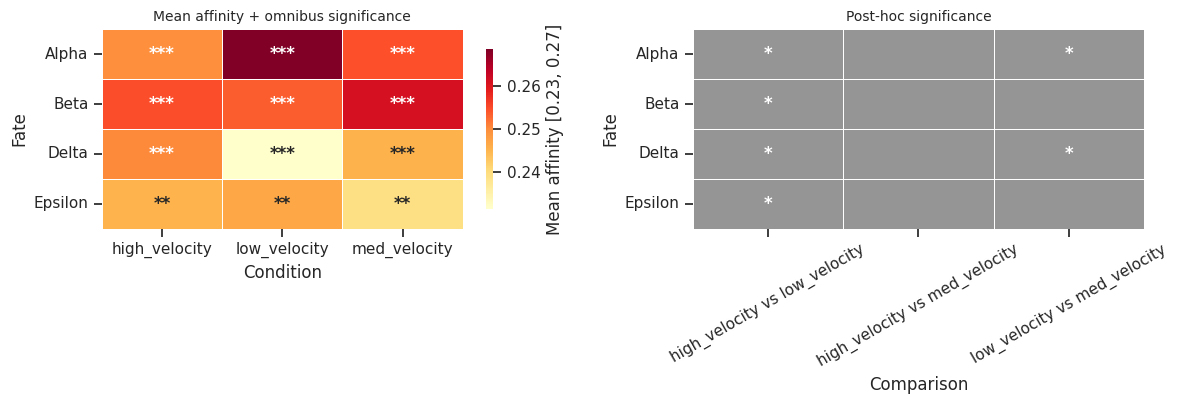

In [10]:
# Omnibus summary: fates x conditions heatmap (also marks post-hoc significance)
fig = mscorer.plot_omnibus_summary(omnibus_df, results, posthoc_df=posthoc_df)
fig.savefig("multi_omnibus_summary.png", dpi=120, bbox_inches="tight")
plt.show()


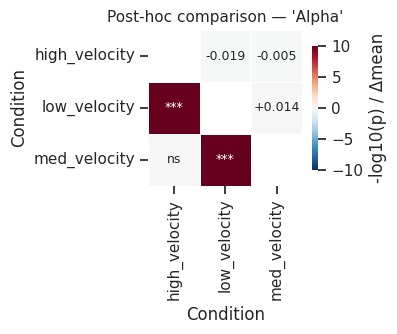

In [11]:
# Per-fate post-hoc heatmap (shows which condition pairs differ)
fig = mscorer.plot_posthoc_heatmap(posthoc_df)
fig.savefig("multi_posthoc_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


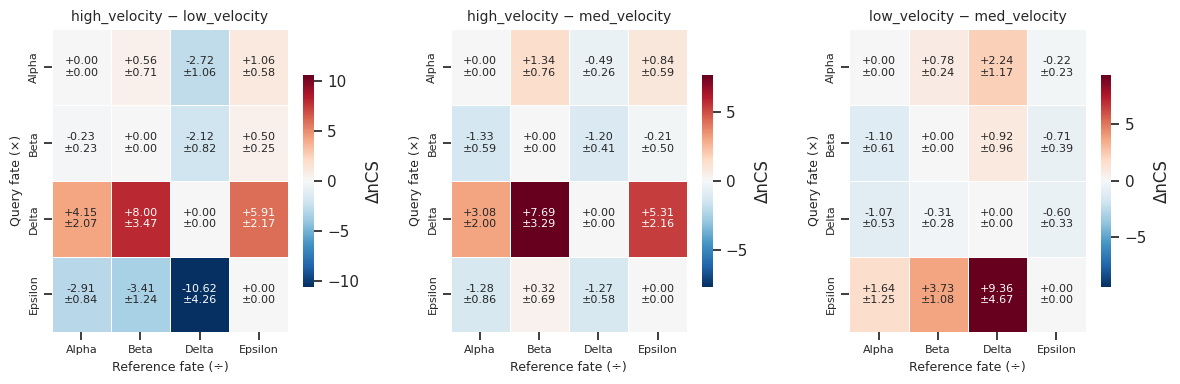

In [12]:
# Pairwise delta grid: ΔCS heatmaps for all condition pairs
fig = mscorer.plot_pairwise_delta_grid(deltas)
fig.savefig("multi_pairwise_deltas.png", dpi=120, bbox_inches="tight")
plt.show()


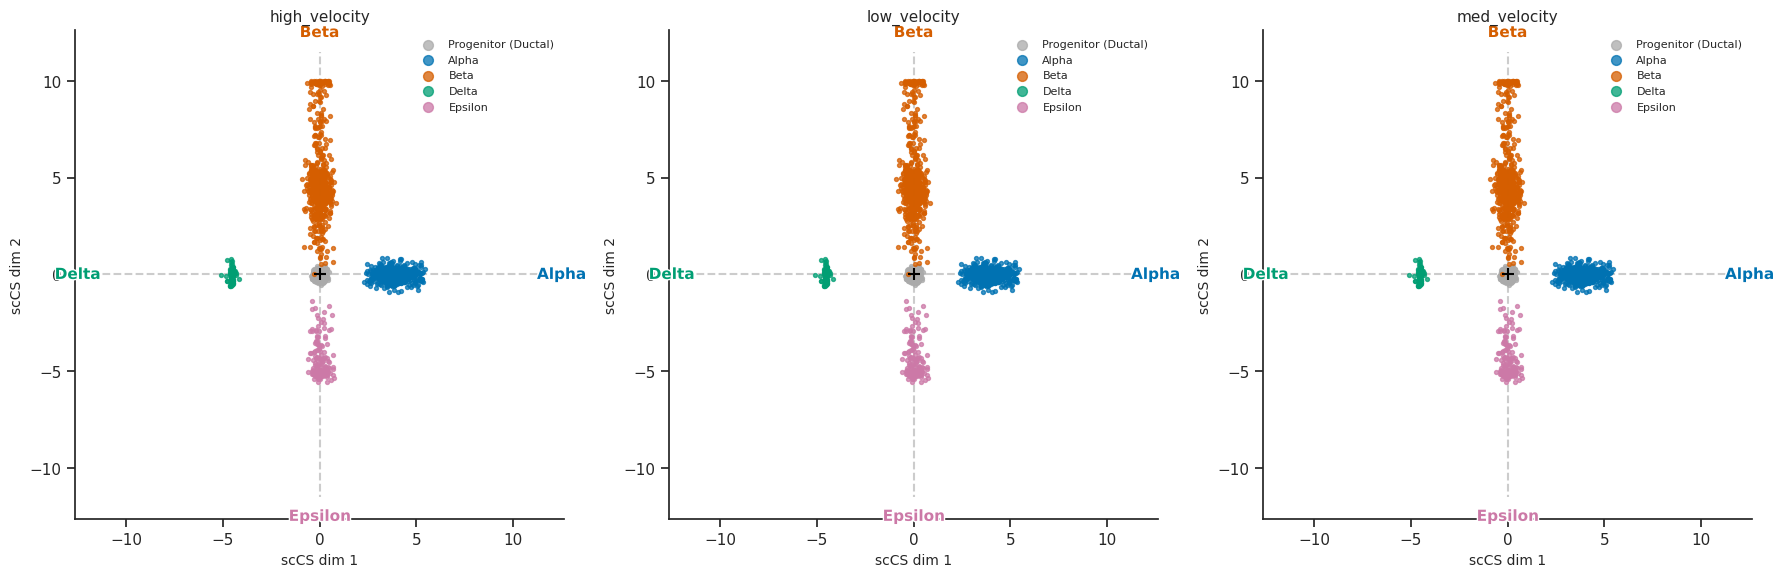

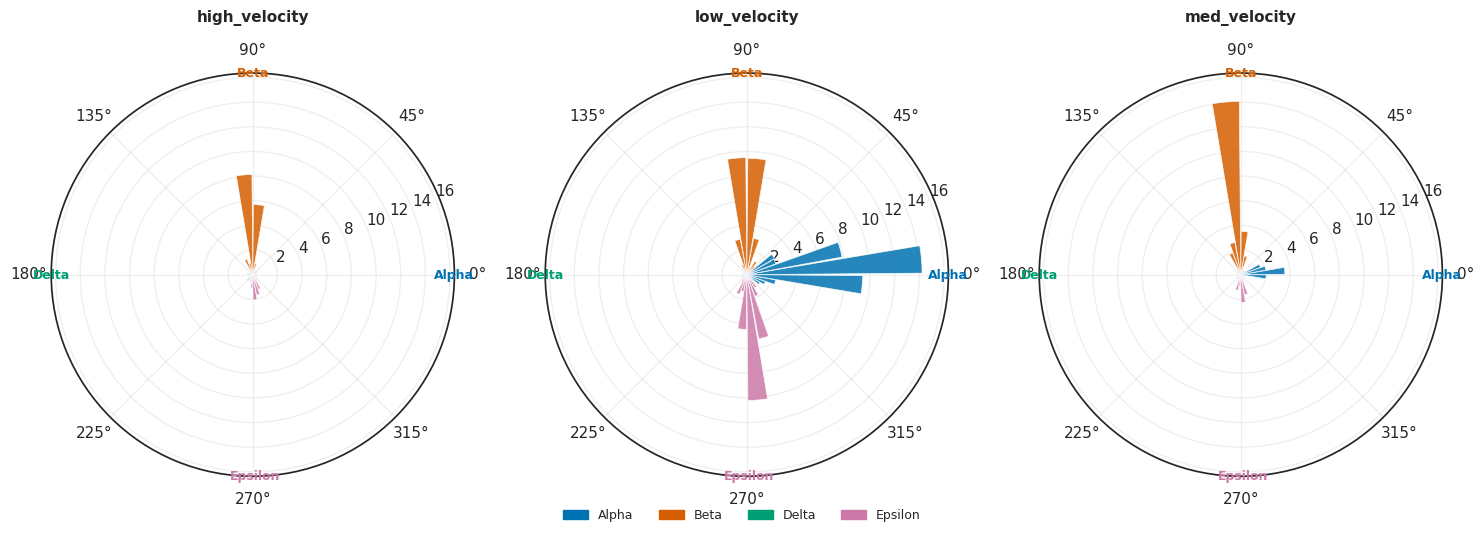

In [13]:
# Standard multi-condition visualizations (shared with PairScorer)
fig = mscorer.plot_star_grid(results)
plt.show()

fig = mscorer.plot_rose_grid(results)
plt.show()


## 10. Driver genes per condition

For each condition we mask the shared embedding's `adata_sub` to that condition, then run the same drivers used in `SingleScorer` — `get_velocity_drivers` and `get_deg_drivers`. The compact `_stack_drivers_by_condition` helper concatenates the per-fate results into one tidy `(condition, fate, gene, ...)` table.

This pattern lets you ask:
- *"Which genes drive each fate decision **within** each condition?"*
- *"Which driver genes are **shared** across all conditions vs **condition-specific**?"*


In [14]:
adata_sub_shared = mscorer._scorer.adata_sub
fate_names = mscorer._scorer._fate_map.fate_names
root_cluster = mscorer._scorer.root
obs_key_used = mscorer._scorer.obs_key

vel_drivers_per_cond = {}
for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    sub = adata_sub_shared[mask].copy()
    vel_drivers_per_cond[cond] = get_velocity_drivers(
        sub,
        fate_names=fate_names,
        obs_key=obs_key_used,
        root=root_cluster,
        n_top_genes=20,
    )

# One compact table: (condition, fate, gene, delta_velocity, mean_velocity, rank)
print("Top velocity drivers (top 5 per fate, per condition):")
_stack_drivers_by_condition(
    vel_drivers_per_cond,
    n_per_fate=5,
    cols=["gene", "delta_velocity", "mean_velocity", "rank"],
)



── Velocity drivers: Alpha (top 20, sorted by delta_velocity) ──
 rank     gene  delta_velocity  mean_velocity
    1   Ptprn2       10.138916      10.179033
    2   Hs6st3        3.034873       3.104659
    3  Fam155a        2.228252       2.250724
    4     Rora        1.744673       1.288695
    5   Kcnma1        1.205779       1.199826
    6    Ndst4        1.142244       1.151202
    7  Stxbp5l        1.115459       1.149110
    8    Glud1        1.078897       0.986085
    9   Dock11        1.037627       1.048391
   10    Rims2        0.969603       1.035052
   11    Kcnb2        0.855988       0.901875
   12      Tnr        0.838274       0.840978
   13    Nlgn1        0.813350       0.828963
   14  Cacna1d        0.786799       0.842683
   15  Cacna1a        0.772174       0.479498
   16 Tmem178b        0.724432       0.726721
   17    Meis2        0.640396       1.320285
   18     Rgs7        0.633256       0.633126
   19    Unc79        0.553534       0.561987
   20    Gnao1

,condition,fate,gene,delta_velocity,mean_velocity,rank
0,high_velocity,Alpha,Ptprn2,10.138916,10.179033,1
1,high_velocity,Alpha,Hs6st3,3.034873,3.104659,2
2,high_velocity,Alpha,Fam155a,2.228252,2.250724,3
3,high_velocity,Alpha,Rora,1.744673,1.288695,4
4,high_velocity,Alpha,Kcnma1,1.205779,1.199826,5
...,...,...,...,...,...,...
55,med_velocity,Epsilon,Ptprn2,2.387180,2.294851,1
56,med_velocity,Epsilon,9030622O22Rik,1.907413,2.330741,2
57,med_velocity,Epsilon,Cacna1c,1.846774,1.849553,3
58,med_velocity,Epsilon,Sorcs1,1.739625,1.754055,4


In [15]:
deg_drivers_per_cond = {}
for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    sub = adata_sub_shared[mask].copy()
    deg_drivers_per_cond[cond] = get_deg_drivers(
        sub,
        fate_names=fate_names,
        obs_key=obs_key_used,
        root=root_cluster,
        n_top_genes=20,
        pval_threshold=0.05,
        logfc_threshold=0.25,
    )

# One compact table: (condition, fate, gene, logfoldchange, pval_adj, pct_*)
print("Top DEG drivers (top 5 per fate, per condition):")
_stack_drivers_by_condition(
    deg_drivers_per_cond,
    n_per_fate=5,
    cols=["gene", "logfoldchange", "pval_adj", "pct_fate", "pct_progenitor"],
)



── DEG drivers: Alpha vs progenitor ──
   Significant: 170  (up: 80, down: 90)
   gene  logfoldchange  pval_adj  pct_fate  pct_progenitor
   Iapp     165.372681  0.001959  1.000000             NaN
    Ttr     143.253738  0.001959  1.000000             NaN
    Pyy      99.835434  0.001959  1.000000             NaN
   Chgb      69.993912  0.001959  1.000000             NaN
   Gnas      59.068867  0.001959  1.000000             NaN
 Pcsk1n      47.226532  0.001959  1.000000             NaN
 Malat1      42.059872  0.007366  1.000000             NaN
 Tmem27      35.617493  0.001959  1.000000             NaN
 Sphkap      34.646255  0.009978  0.833333             NaN
  Rab37      31.131083  0.009978  0.833333             NaN
    Cpe      26.859491  0.001959  1.000000             NaN
   Chga      24.825945  0.001959  1.000000             NaN
   Rbp4      23.749779  0.001959  1.000000             NaN
   Bex2      17.820747  0.001959  1.000000             NaN
   Scg3      16.006983  0.009978  0

,condition,fate,gene,logfoldchange,pval_adj,pct_fate,pct_progenitor
0,high_velocity,Alpha,Iapp,165.372681,1.959313e-03,1.00,NaN
1,high_velocity,Alpha,Ttr,143.253738,1.959313e-03,1.00,NaN
2,high_velocity,Alpha,Pyy,99.835434,1.959313e-03,1.00,NaN
3,high_velocity,Alpha,Chgb,69.993912,1.959313e-03,1.00,NaN
4,high_velocity,Alpha,Gnas,59.068867,1.959313e-03,1.00,NaN
...,...,...,...,...,...,...,...
50,med_velocity,Epsilon,Ghrl,485.379456,2.998483e-22,1.00,NaN
51,med_velocity,Epsilon,Pyy,163.205170,3.450739e-19,0.95,NaN
52,med_velocity,Epsilon,Rbp4,99.282028,2.998483e-22,1.00,NaN
53,med_velocity,Epsilon,Lrpprc,56.673809,3.247204e-18,0.90,NaN


In [16]:
# Driver overlap across all 3 conditions:
# rows = (fate, gene); columns = condition presence + n_conds + shared_all flag.
overlap = _driver_overlap(deg_drivers_per_cond, n_top=10, gene_col="gene")

# Cross-tab: how many genes are shared by exactly k conditions, per fate?
overlap.groupby(["fate", "n_conds"]).size().unstack(fill_value=0)


n_conds,1,2,3
fate,,,
Alpha,9,3,5
Beta,4,4,6
Epsilon,12,3,4


In [17]:
# Show the genes that are condition-specific (n_conds == 1) for each fate.
specific = overlap[overlap["n_conds"] == 1]
specific.head(30)


,fate,gene,high_velocity,low_velocity,med_velocity,n_conds,shared_all
0,Alpha,BC048546,False,False,True,1,False
3,Alpha,Gnao1,True,False,False,1,False
6,Alpha,Irx2,False,True,False,1,False
7,Alpha,Isl1,False,True,False,1,False
9,Alpha,Pcsk1n,True,False,False,1,False
10,Alpha,Pcsk2,False,True,False,1,False
13,Alpha,Slc38a5,False,False,True,1,False
14,Alpha,Sphkap,True,False,False,1,False
15,Alpha,Tmem27,True,False,False,1,False
17,Beta,Chga,False,True,False,1,False


## 11. Pathway enrichment per condition

We run `run_enrichment_per_fate` on the per-condition DEG drivers (offline-safe: wrapped in try/except). The compact `_stack_enrichment_by_condition` helper builds one tidy table with columns `(condition, fate, direction, Term, Adjusted P-value, Overlap, ...)`.

> The cell will be empty in published HTML if `gseapy` cannot reach Enrichr (no internet during doc build). Run interactively for live results.


In [18]:
enrichment_per_cond = {}
try:
    for cond in mscorer.conditions:
        enrichment_per_cond[cond] = run_enrichment_per_fate(
            deg_drivers_per_cond[cond],
            fate_names=fate_names,
            organism="mouse",
            pval_threshold=0.05,
            logfc_threshold=0.25,
            plot=False,
            n_top_pathways=10,
        )
    display(_stack_enrichment_by_condition(enrichment_per_cond, n_per_group=3))
except Exception as e:
    print(f"Enrichment skipped (offline?): {e}")



  Pathway enrichment: Alpha
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 80
  Down-regulated genes: 90

  [up] Significant terms: 1
       Gene_set                      Term Overlap  Adjusted P-value
KEGG_2019_Mouse Thyroid hormone synthesis    4/73          0.026393

  [down] Significant terms: 107
                  Gene_set                                                                             Term Overlap  Adjusted P-value
GO_Biological_Process_2021         SRP-dependent cotranslational protein targeting to membrane (GO:0006614)   25/90      4.833486e-36
GO_Biological_Process_2021                                             cytoplasmic translation (GO:0002181)   25/93      5.612907e-36
GO_Biological_Process_2021                       cotranslational protein targeting to membrane (GO:0006613)   25/94      5.612907e-36
GO_Biological_Process_2021                                             protein targeting to ER (GO:0045

,condition,fate,direction,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,high_velocity,Alpha,up,KEGG_2019_Mouse,Thyroid hormone synthesis,4/73,2.094671e-04,2.639285e-02,0,0,15.141876,128.265986,TTR;GPX3;GNAS;PDIA4
1,high_velocity,Alpha,down,GO_Biological_Process_2021,SRP-dependent cotranslational protein targetin...,25/90,5.142006e-39,4.833486e-36,0,0,117.426036,10352.675635,RPL3;RPL32;RPLP1;RPL12;RPLP0;RPL10A;RPL7;RPS4X...
2,high_velocity,Alpha,down,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),25/93,1.319036e-38,5.612907e-36,0,0,112.228507,9788.719925,RPL3;RPL32;RPLP1;RPL12;RPLP0;RPL10A;RPL7;RPS4X...
3,high_velocity,Alpha,down,GO_Biological_Process_2021,cotranslational protein targeting to membrane ...,25/94,1.791353e-38,5.612907e-36,0,0,110.596433,9612.517927,RPL3;RPL32;RPLP1;RPL12;RPLP0;RPL10A;RPL7;RPS4X...
4,high_velocity,Beta,up,KEGG_2019_Mouse,Protein processing in endoplasmic reticulum,27/163,3.186142e-13,7.997215e-11,0,0,6.796547,195.569247,ERO1LB;RPN2;TUSC3;HSPA4L;RPN1;SEL1L;RRBP1;RNF5...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,med_velocity,Epsilon,up,KEGG_2019_Mouse,Lysosome,14/124,3.691181e-07,4.410919e-05,0,0,6.072906,89.952783,CD164;CD63;ATP6V0B;ATP6AP1;CTSZ;HEXA;CLTB;CTSO...
60,med_velocity,Epsilon,up,KEGG_2019_Mouse,Protein processing in endoplasmic reticulum,16/163,3.802516e-07,4.410919e-05,0,0,5.209209,77.004778,HSPA8;RPN2;HSPA5;TUSC3;SSR2;HSPA4L;RPN1;EDEM2;...
61,med_velocity,Epsilon,down,GO_Biological_Process_2021,cotranslational protein targeting to membrane ...,31/94,5.836188e-31,6.997589e-28,0,0,29.189803,2032.079063,RPL3;ARL6IP1;RPL32;RPL10;RPLP1;RPL12;RPLP0;RPL...
62,med_velocity,Epsilon,down,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),31/93,3.975154e-31,6.997589e-28,0,0,29.662121,2076.350692,RPL3;RPL32;RPL10;RPLP1;RPL12;RPLP0;RPL11;RPL10...


## 12. Expression trends along fate arms — per condition

`plot_expression_trends` shows how marker genes evolve along each fate arm. Running it once per condition on the masked `adata_sub` puts the per-condition curves side by side, so you can spot timing shifts, magnitude changes, or qualitatively different trajectories.

We use `x_axis="affinity"` here — distance along each fate arm in the shared embedding. `"pseudotime"` and `"radial_distance"` are also supported.



--- high_velocity (n=633 cells) ---


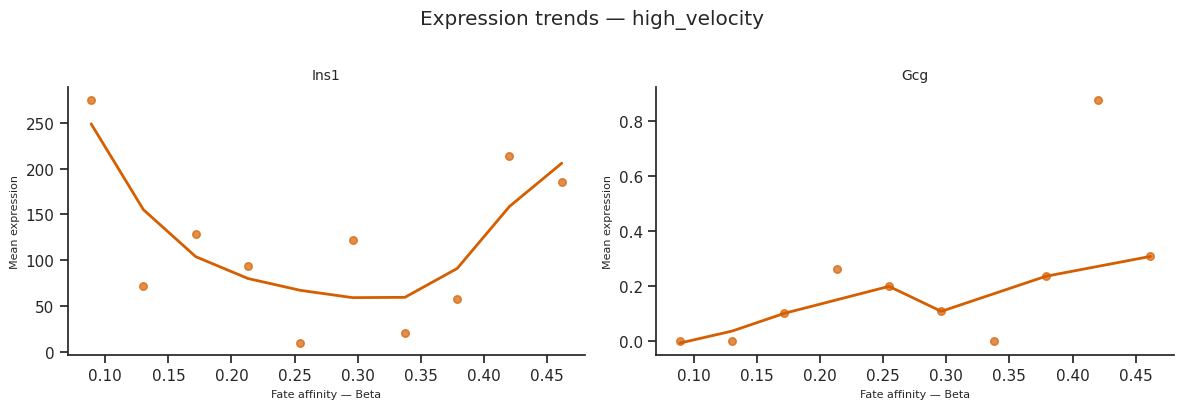


--- low_velocity (n=957 cells) ---


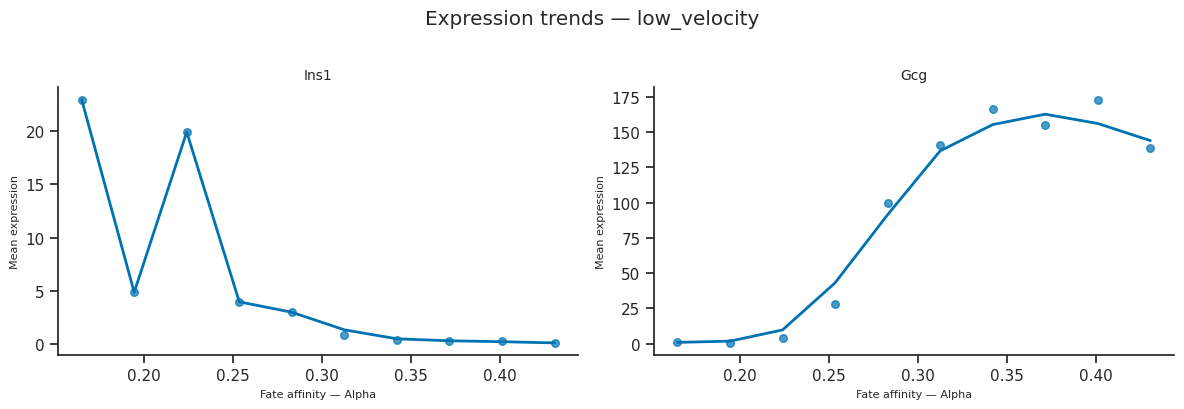


--- med_velocity (n=610 cells) ---


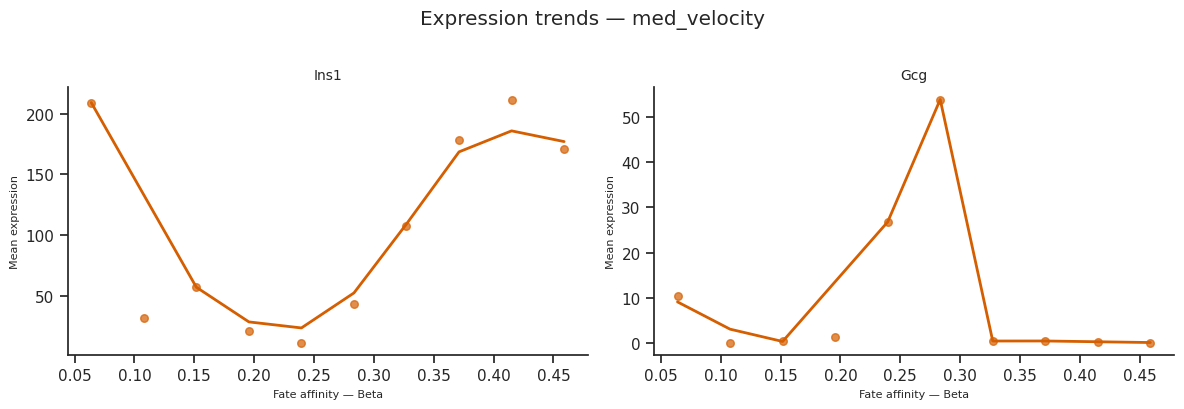

In [19]:
from dataclasses import replace

genes = ["Ins1", "Gcg"]  # Beta-cell + Alpha-cell markers
genes = [g for g in genes if g in adata_sub_shared.var_names]

# Use cell_obs_names from each per-condition result to mask the shared
# CommitmentScoreResult to that condition (plot_expression_trends expects
# a result whose cell_obs_names index into the passed AnnData).
cell_names_full = np.array(adata_sub_shared.obs_names)
for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    res_full = results[cond]
    if res_full.cell_scores is None:
        print(f"\n--- {cond}: no cell-level scores; rerun score_all_conditions(cell_level=True). Skipping. ---")
        continue
    # Some results store full-shape arrays (one per shared-embedding cell)
    # while others store only this-condition cells; handle both.
    if res_full.cell_scores.shape[0] == adata_sub_shared.n_obs:
        cs = res_full.cell_scores[mask]
        cnames = cell_names_full[mask]
        nne = res_full.nn_cell_entropy[mask] if res_full.nn_cell_entropy is not None else None
    else:
        cs = res_full.cell_scores
        cnames = np.asarray(res_full.cell_obs_names)
        nne = res_full.nn_cell_entropy
    res_masked = replace(
        res_full,
        cell_scores=cs,
        cell_obs_names=cnames,
        nn_cell_entropy=nne,
    )
    print(f"\n--- {cond} (n={cs.shape[0]} cells) ---")
    try:
        fig = plot_expression_trends(
            adata_sub_shared,
            res_masked,
            genes=genes,
            x_axis="affinity",
            figsize=(12, 4),
        )
        plt.suptitle(f"Expression trends — {cond}", y=1.02)
        plt.show()
    except Exception as e:
        print(f"Expression trends failed for {cond}: {e}")

## 13. Transfer per-cell labels back to the full AnnData

`transfer_labels` writes per-cell, per-condition affinity scores and dominant fate labels back to the FULL adata as new `obs` columns (named `cs_{fate}_{condition}` and `cs_dominant_fate_{condition}`). This lets you use the scCS outputs in downstream Scanpy / scVelo workflows — UMAP coloring, marker discovery, etc.


In [20]:
# MultiScorer.transfer_labels writes cs_{condition}_{...} columns to
# mscorer.adata internally — no positional adata argument needed.
mscorer.transfer_labels(results, prefix="cs_")

new_cols = [c for c in mscorer.adata.obs.columns
            if c.startswith("cs_") and any(cond in c for cond in mscorer.conditions)]
print(f"New columns written to adata.obs ({len(new_cols)}):")
for c in new_cols[:15]:
    print(f"  - {c}")
if len(new_cols) > 15:
    print(f"  ... +{len(new_cols) - 15} more")

[scCS] Labels transferred to adata.obs for 2200 / 3696 cells. Columns: ['cs_high_velocity_Alpha', 'cs_high_velocity_Beta', 'cs_high_velocity_Delta', 'cs_high_velocity_Epsilon', 'cs_high_velocity_dominant_fate', 'cs_high_velocity_entropy']
[scCS] Labels transferred to adata.obs for 2200 / 3696 cells. Columns: ['cs_low_velocity_Alpha', 'cs_low_velocity_Beta', 'cs_low_velocity_Delta', 'cs_low_velocity_Epsilon', 'cs_low_velocity_dominant_fate', 'cs_low_velocity_entropy']
[scCS] Labels transferred to adata.obs for 2200 / 3696 cells. Columns: ['cs_med_velocity_Alpha', 'cs_med_velocity_Beta', 'cs_med_velocity_Delta', 'cs_med_velocity_Epsilon', 'cs_med_velocity_dominant_fate', 'cs_med_velocity_entropy']
New columns written to adata.obs (18):
  - cs_high_velocity_Alpha
  - cs_high_velocity_Beta
  - cs_high_velocity_Delta
  - cs_high_velocity_Epsilon
  - cs_high_velocity_dominant_fate
  - cs_high_velocity_entropy
  - cs_low_velocity_Alpha
  - cs_low_velocity_Beta
  - cs_low_velocity_Delta
  - cs

In [21]:
# Quick UMAP showing dominant fate per condition (if UMAP is available).
# transfer_labels wrote columns to mscorer.adata, so plot from there.
full = mscorer.adata
if "X_umap" not in full.obsm:
    sc.pp.neighbors(full, n_neighbors=15) if "distances" not in full.obsp else None
    sc.tl.umap(full)

dom_cols = [c for c in full.obs.columns if c.startswith("cs_dominant_fate_")]
if dom_cols:
    sc.pl.umap(full, color=dom_cols, ncols=len(mscorer.conditions),
               wspace=0.4, show=True)
else:
    print("No cs_dominant_fate_* columns found in mscorer.adata.obs — "
          "make sure transfer_labels() ran successfully above.")

No cs_dominant_fate_* columns found in mscorer.adata.obs — make sure transfer_labels() ran successfully above.


## 14. Summary — scCS 3+ condition workflow

```python
import scCS

# 1. Add condition column (3+ levels) to adata.obs
adata.obs["condition"] = ...     # e.g., 'control', 'drug_A', 'drug_B'
adata.obs["sample"]    = ...     # biological replicates

# 2. Initialize MultiScorer
mscorer = scCS.MultiScorer(
    adata,
    root="Ductal",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_obs_key="condition",
    obs_key="clusters",
)

# 3. Build SHARED embedding on pooled data, then fit
mscorer.build_embedding(ordering_metric="velocity_pseudotime")
mscorer.fit()
# (optional) mscorer.refit_pseudotime() — only call when the subset has
# a connected velocity_graph; otherwise stick with velocity_pseudotime.

# ── Tier 1 — score each condition ────────────────────────────────────────────
results = mscorer.score_all_conditions(cell_level=True, n_bootstrap=200)

# ── Tier 2 — omnibus + post-hoc ──────────────────────────────────────────────
omnibus_df = mscorer.compare_omnibus(results, test="kruskal")
posthoc_df = mscorer.compare_posthoc(
    results, omnibus_results=omnibus_df, method="dunn",
    pval_correction="bonferroni", pval_threshold=0.05,
)
deltas     = mscorer.compute_pairwise_deltas(n_bootstrap=100)

# ── Tier 3 — mixed model with reference contrasts ────────────────────────────
contrasts_df = mscorer.fit_mixed_model_contrasts(
    results, ref_condition="control", replicate_key="sample"
)

# ── Visualizations ───────────────────────────────────────────────────────────
mscorer.plot_omnibus_summary(omnibus_df, results, posthoc_df=posthoc_df)
mscorer.plot_posthoc_heatmap(posthoc_df)
mscorer.plot_pairwise_delta_grid(deltas)
mscorer.plot_star_grid(results)
mscorer.plot_rose_grid(results)

# ── Downstream §10 — driver genes per condition ──────────────────────────────
# Loop conditions: mask adata_sub per condition -> get_velocity_drivers /
# get_deg_drivers -> _stack_drivers_by_condition -> one tidy table.

# ── Downstream §11 — pathway enrichment per condition ────────────────────────
# Loop conditions: run_enrichment_per_fate on each cond's DEG drivers ->
# _stack_enrichment_by_condition -> one tidy table.

# ── Downstream §12 — expression trends per condition ─────────────────────────
# Loop conditions: build a per-condition CommitmentScoreResult via
# dataclasses.replace, masking cell_scores/cell_obs_names/nn_cell_entropy
# to that condition's cells, then plot_expression_trends.

# ── Downstream §13 — transfer labels back to mscorer.adata ───────────────────
mscorer.transfer_labels(results, prefix="cs_")
# Writes cs_{condition}_{fate} + cs_{condition}_dominant_fate + cs_{condition}_entropy
```

### Interpretation guide

| Result | Interpretation |
|---|---|
| Omnibus q < 0.05 for a fate | Affinity for that fate differs across at least one condition pair |
| Post-hoc q < 0.05 for (a, b) | That specific condition pair drives the difference |
| ΔnCS CI excludes 0 | Pairwise commitment shift is significant |
| Mixed-model contrast coef significant | Condition effect on affinity, controlling for replicate |
| Top driver gene in only 1 condition | Condition-specific regulator candidate |
| Pathway enriched in only 1 condition | Differentially activated pathway |
| Expression curve shifted in 1 condition | Altered developmental timing for that gene |

For **2-condition** comparisons see `Pairwise Comparison Analysis.ipynb`; for **single-condition** analysis see `Single Condition Analysis.ipynb`.
